In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import os
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

In [73]:
folder = os.fsencode("../Code/seasons/Test")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("../Code/seasons/Test/" + filename)
        dataframes.append(df)

folder = os.fsencode("../Code/seasons/Train")     
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("../Code/seasons/Train/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

2223.csv
2324.csv
2425.csv
2526.csv
0607.csv
0708.csv
0809.csv
0910.csv
1011.csv
1112.csv
1213.csv
1314.csv
1415.csv
1516.csv
1617.csv
1718.csv
1819.csv
1920.csv
2021.csv
2122.csv


In [75]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "B365H", "B365D", "B365A"
]]

In [77]:
data["HomeWin"] = np.where(data["FTR"] == "H", 1, 0)
data["Draw"] = np.where(data["FTR"] == "D", 1, 0)
data["AwayWin"] = np.where(data["FTR"] == "A", 1, 0)

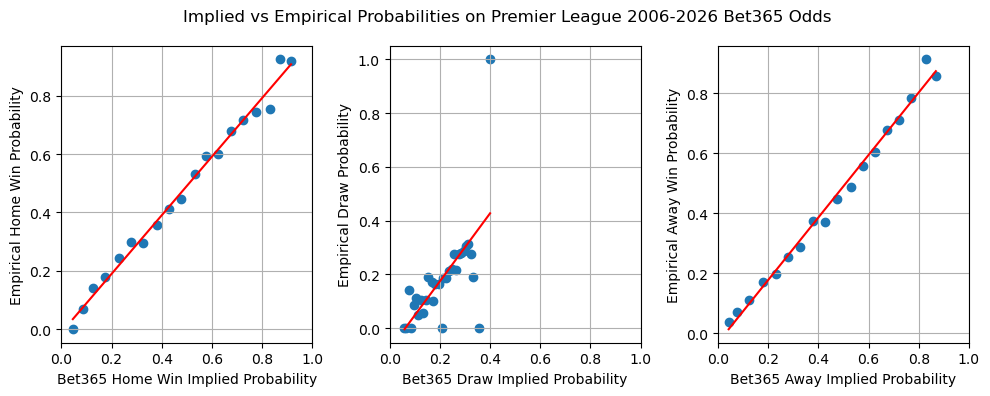

In [208]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

data["impH"] = 1 / data["B365H"]
data['odds_bin'] = pd.cut(data['impH'], bins=np.arange(0, 1.01, 0.05))  # Adjust bin size as needed
grouped = data.groupby('odds_bin').agg(
    avg_odds=('impH', 'mean'),
    empirical_prob=('HomeWin', 'mean'),
    count=('HomeWin', 'count')
).dropna()
X = grouped['avg_odds'].values.reshape(-1, 1)
y = grouped['empirical_prob'].values

homeModel = LinearRegression()
homeModel.fit(X, y)

grouped['predicted_prob'] = homeModel.predict(X)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].scatter(grouped['avg_odds'], grouped['empirical_prob'], label='Empirical')
ax[0].grid()
ax[0].plot(grouped['avg_odds'], grouped['predicted_prob'], color='red', label='Linear Fit')
ax[0].set_xlabel('Bet365 Home Win Implied Probability')
ax[0].set_ylabel('Empirical Home Win Probability')
ax[0].set_xlim(0,1)

data["impD"] = 1 / data["B365D"]
data['odds_binD'] = pd.cut(data['impD'], bins=np.arange(0, 0.5, 0.01))  # Adjust bin size as needed
grouped = data.groupby('odds_binD').agg(
    avg_oddsD=('impD', 'mean'),
    empirical_probD=('Draw', 'mean'),
    count=('Draw', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsD'].values.reshape(-1, 1)
y = grouped['empirical_probD'].values

# Fit model
drawModel = LinearRegression()
drawModel.fit(X, y)

# Predict
grouped['predicted_probD'] = drawModel.predict(X)

ax[1].scatter(grouped['avg_oddsD'], grouped['empirical_probD'], label='Empirical')
ax[1].plot(grouped['avg_oddsD'], grouped['predicted_probD'], color='red', label='Linear Fit')
ax[1].set_xlabel('Bet365 Draw Implied Probability')
ax[1].set_ylabel('Empirical Draw Probability')
ax[1].set_xlim(0,1)
ax[1].grid()

data["impA"] = 1 / data["B365A"]
data['odds_binA'] = pd.cut(data['impA'], bins=np.arange(0, 1, 0.05))  # Adjust bin size as needed
grouped = data.groupby('odds_binA').agg(
    avg_oddsA=('impA', 'mean'),
    empirical_probA=('AwayWin', 'mean'),
    count=('AwayWin', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsA'].values.reshape(-1, 1)
y = grouped['empirical_probA'].values

# Fit model
awayModel = LinearRegression()
awayModel.fit(X, y)

# Predict
grouped['predicted_probA'] = awayModel.predict(X)

ax[2].scatter(grouped['avg_oddsA'], grouped['empirical_probA'], label='Empirical')
ax[2].plot(grouped['avg_oddsA'], grouped['predicted_probA'], color='red', label='Linear Fit')
ax[2].set_xlabel('Bet365 Away Implied Probability')
ax[2].set_ylabel('Empirical Away Win Probability')
ax[2].grid()
ax[2].set_xlim(0,1)
mid = (fig.subplotpars.right + fig.subplotpars.left)/2
plt.suptitle("Implied vs Empirical Probabilities on Premier League 2006-2026 Bet365 Odds", x=mid)
plt.tight_layout()
plt.savefig("linReg.pdf")
plt.show()

In [192]:
print(awayModel.coef_)
print(awayModel.intercept_)

[1.04191485]
-0.030359595501621095


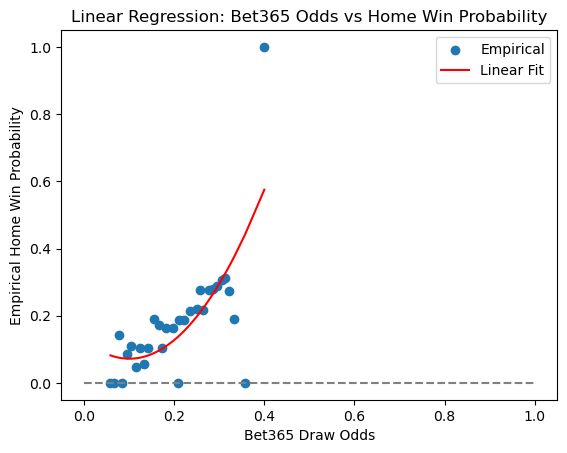

In [196]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

data["impD"] = 1 / data["B365D"]
data['odds_binD'] = pd.cut(data['impD'], bins=np.arange(0, 1, 0.01))  # Adjust bin size as needed
grouped = data.groupby('odds_binD').agg(
    avg_oddsD=('impD', 'mean'),
    empirical_probD=('Draw', 'mean'),
    count=('Draw', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsD'].values.reshape(-1, 1)
y = grouped['empirical_probD'].values


# Fit model
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Predict
grouped['predicted_probD'] = model.predict(X_poly)

plt.scatter(grouped['avg_oddsD'], grouped['empirical_probD'], label='Empirical')
plt.plot(grouped['avg_oddsD'], grouped['predicted_probD'], color='red', label='Linear Fit')
plt.xlabel('Bet365 Draw Odds')
plt.ylabel('Empirical Home Win Probability')
plt.title('Linear Regression: Bet365 Odds vs Home Win Probability')
plt.hlines(0, 0, 1, color="grey", linestyle="dashed")
plt.legend()
plt.show()


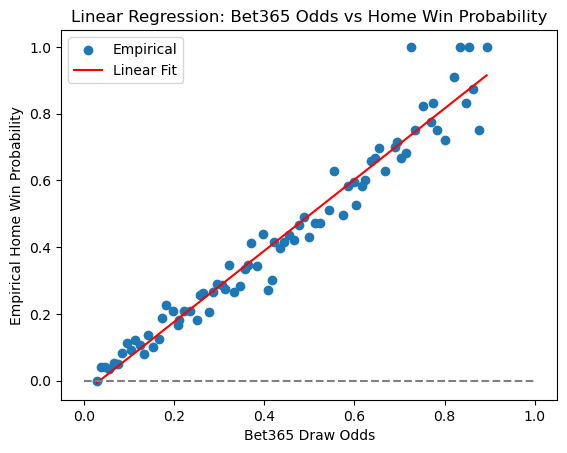

In [99]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Example: Home win regression
data["impA"] = 1 / data["B365A"]
data['odds_binA'] = pd.cut(data['impA'], bins=np.arange(0, 1, 0.01))  # Adjust bin size as needed
grouped = data.groupby('odds_binA').agg(
    avg_oddsA=('impA', 'mean'),
    empirical_probA=('AwayWin', 'mean'),
    count=('AwayWin', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsA'].values.reshape(-1, 1)
y = grouped['empirical_probA'].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predict
grouped['predicted_probA'] = model.predict(X)
import matplotlib.pyplot as plt

plt.scatter(grouped['avg_oddsA'], grouped['empirical_probA'], label='Empirical')
plt.plot(grouped['avg_oddsA'], grouped['predicted_probA'], color='red', label='Linear Fit')
plt.xlabel('Bet365 Draw Odds')
plt.ylabel('Empirical Home Win Probability')
plt.title('Linear Regression: Bet365 Odds vs Home Win Probability')
plt.hlines(0, 0, 1, color="grey", linestyle="dashed")
plt.legend()
plt.show()


In [101]:
data.describe()

,FTHG,FTAG,B365H,B365D,B365A,HomeWin,Draw,AwayWin,impH,impD,impA
count,7210.000000,7210.000000,7210.000000,7210.000000,7210.00000,7211.000000,7211.000000,7211.000000,7210.000000,7210.000000,7210.000000
mean,1.549376,1.206657,2.835516,4.097025,4.83638,0.455415,0.243378,0.301068,0.466798,0.258780,0.321252
std,1.319998,1.175422,2.032006,1.251371,4.13913,0.498043,0.429151,0.458754,0.201940,0.051299,0.182558
min,0.000000,0.000000,1.060000,2.500000,1.12000,0.000000,0.000000,0.000000,0.043478,0.058824,0.024390
25%,1.000000,0.000000,1.660000,3.400000,2.35500,0.000000,0.000000,0.000000,0.322581,0.230947,0.181818
50%,1.000000,1.000000,2.200000,3.600000,3.40000,0.000000,0.000000,0.000000,0.454545,0.277778,0.294118
75%,2.000000,2.000000,3.100000,4.330000,5.50000,1.000000,0.000000,1.000000,0.602410,0.294118,0.424634
max,9.000000,9.000000,23.000000,17.000000,41.00000,1.000000,1.000000,1.000000,0.943396,0.400000,0.892857


In [120]:
data['odds_bin'] = pd.cut(data['impH'], bins=np.arange(0, 1.05, 0.05))  # Adjust bin size as needed
grouped = data.groupby('odds_bin').agg(
    avg_odds=('impH', 'mean'),
    empirical_prob=('HomeWin', 'mean'),
    count=('HomeWin', 'count')
).dropna()

grouped

,avg_odds,empirical_prob,count
odds_bin,,,
"(0.0, 0.05]",0.045549,0.000000,4
"(0.05, 0.1]",0.085761,0.068966,116
"(0.1, 0.15]",0.127259,0.140078,257
"(0.15, 0.2]",0.175725,0.178499,493
"(0.2, 0.25]",0.230255,0.243243,370
"(0.25, 0.3]",0.277658,0.297376,343
"(0.3, 0.35]",0.327068,0.295880,534
"(0.35, 0.4]",0.382442,0.356028,705
"(0.4, 0.45]",0.427647,0.413043,690


In [118]:
print(data['impH'].max())


0.9433962264150942


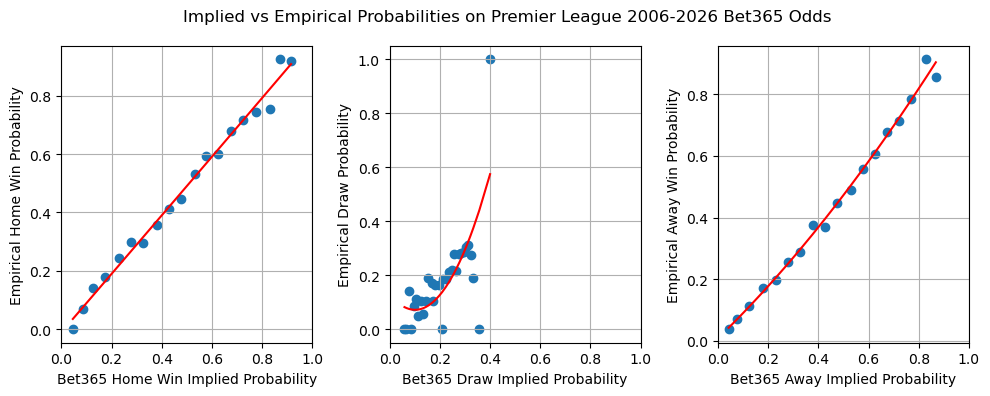

In [216]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

data["impH"] = 1 / data["B365H"]
data['odds_bin'] = pd.cut(data['impH'], bins=np.arange(0, 1.01, 0.05))  # Adjust bin size as needed
grouped = data.groupby('odds_bin').agg(
    avg_odds=('impH', 'mean'),
    empirical_prob=('HomeWin', 'mean'),
    count=('HomeWin', 'count')
).dropna()
X = grouped['avg_odds'].values.reshape(-1, 1)
y = grouped['empirical_prob'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

homeModel = LinearRegression()
homeModel.fit(X_poly, y)

grouped['predicted_prob'] = homeModel.predict(X_poly)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].scatter(grouped['avg_odds'], grouped['empirical_prob'], label='Empirical')
ax[0].grid()
ax[0].plot(grouped['avg_odds'], grouped['predicted_prob'], color='red', label='Linear Fit')
ax[0].set_xlabel('Bet365 Home Win Implied Probability')
ax[0].set_ylabel('Empirical Home Win Probability')
ax[0].set_xlim(0,1)

data["impD"] = 1 / data["B365D"]
data['odds_binD'] = pd.cut(data['impD'], bins=np.arange(0, 0.5, 0.01))  # Adjust bin size as needed
grouped = data.groupby('odds_binD').agg(
    avg_oddsD=('impD', 'mean'),
    empirical_probD=('Draw', 'mean'),
    count=('Draw', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsD'].values.reshape(-1, 1)
y = grouped['empirical_probD'].values

X_poly = poly.fit_transform(X)

# Fit model
drawModel = LinearRegression()
drawModel.fit(X_poly, y)

# Predict
grouped['predicted_probD'] = drawModel.predict(X_poly)

ax[1].scatter(grouped['avg_oddsD'], grouped['empirical_probD'], label='Empirical')
ax[1].plot(grouped['avg_oddsD'], grouped['predicted_probD'], color='red', label='Linear Fit')
ax[1].set_xlabel('Bet365 Draw Implied Probability')
ax[1].set_ylabel('Empirical Draw Probability')
ax[1].set_xlim(0,1)
ax[1].grid()

data["impA"] = 1 / data["B365A"]
data['odds_binA'] = pd.cut(data['impA'], bins=np.arange(0, 1, 0.05))  # Adjust bin size as needed
grouped = data.groupby('odds_binA').agg(
    avg_oddsA=('impA', 'mean'),
    empirical_probA=('AwayWin', 'mean'),
    count=('AwayWin', 'count')
).dropna()
# Prepare data
X = grouped['avg_oddsA'].values.reshape(-1, 1)
y = grouped['empirical_probA'].values

X_poly = poly.fit_transform(X)

# Fit model
awayModel = LinearRegression()
awayModel.fit(X_poly, y)

# Predict
grouped['predicted_probA'] = awayModel.predict(X_poly)

ax[2].scatter(grouped['avg_oddsA'], grouped['empirical_probA'], label='Empirical')
ax[2].plot(grouped['avg_oddsA'], grouped['predicted_probA'], color='red', label='Linear Fit')
ax[2].set_xlabel('Bet365 Away Implied Probability')
ax[2].set_ylabel('Empirical Away Win Probability')
ax[2].grid()
ax[2].set_xlim(0,1)
mid = (fig.subplotpars.right + fig.subplotpars.left)/2
plt.suptitle("Implied vs Empirical Probabilities on Premier League 2006-2026 Bet365 Odds", x=mid)
plt.tight_layout()
plt.savefig("quadReg.pdf")
plt.show()

In [218]:
print(homeModel.coef_)
print(homeModel.intercept_)

print(drawModel.coef_)
print(drawModel.intercept_)

print(awayModel.coef_)
print(awayModel.intercept_)

[0.99829778 0.00531662]
-0.010284473967461405
[-1.13380679  5.6203745 ]
0.12922414762452739
[0.78956274 0.27895668]
0.008388743199307602
